# SVD Analysis on Pretrained Models for CIFAR-10

This notebook demonstrates how Singular Value Decomposition (SVD) can be applied to weight matrices of pretrained neural networks to analyze their compression and performance trade-offs. We'll use a pretrained model on CIFAR-10 and examine how reducing the rank of weight matrices through SVD affects classification accuracy.

## Overview
1. Load and preprocess CIFAR-10 dataset
2. Load a pretrained model
3. Apply SVD to weight matrices
4. Reconstruct models with different numbers of singular values
5. Compare accuracy on train and test data
6. Visualize the results

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import copy
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: mps


## 2. Load and Preprocess CIFAR-10 Dataset

In [2]:
# Define transforms for CIFAR-10
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create data loaders
batch_size = 128
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# CIFAR-10 class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Dataset loaded: {len(trainset)} training samples, {len(testset)} test samples")
print(f"Number of classes: {len(classes)}")

Loading CIFAR-10 dataset...
Dataset loaded: 50000 training samples, 10000 test samples
Number of classes: 10


## 3. Load Pretrained Model

In [3]:
# Create a ResNet18 model for CIFAR-10
# Note: Standard torchvision ResNet18 is pretrained on ImageNet (224x224 images, 1000 classes)
# For CIFAR-10 (32x32 images, 10 classes), we need to adapt the architecture

print("Creating ResNet18 adapted for CIFAR-10...")

# Option 1: Use standard ResNet18 and adapt it for CIFAR-10
model = torchvision.models.resnet18(pretrained=True)  # Start without ImageNet pretraining

# Modify the first conv layer for CIFAR-10's smaller image size (32x32)
# Original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
# CIFAR-10 adapted: smaller kernel and stride to preserve spatial information
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # Remove maxpooling to preserve spatial dimensions

# Modify the final layer for CIFAR-10 (10 classes)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

# Move model to device
model = model.to(device)

# Initialize weights randomly (since we're not using ImageNet pretraining)
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

model.apply(init_weights)

print(f"Model created with {sum(p.numel() for p in model.parameters())} total parameters")
print(f"Note: This model uses random initialization, not ImageNet pretraining")
print(f"For meaningful SVD analysis, you would typically want to train this model first on CIFAR-10")
print(f"\nModel architecture:")
print(model)

Creating ResNet18 adapted for CIFAR-10...


/Users/christoffer/Documents/Thesis/repo/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/christoffer/Documents/Thesis/repo/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model created with 11173962 total parameters
Note: This model uses random initialization, not ImageNet pretraining
For meaningful SVD analysis, you would typically want to train this model first on CIFAR-10

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=

In [4]:
# Optional: Quick training function for CIFAR-10 (uncomment to use)
def train_model_on_cifar10(model, trainloader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {running_loss/(batch_idx+1):.3f}, Acc: {100.*correct/total:.2f}%')
        
        scheduler.step()
        print(f'Epoch {epoch+1}/{epochs} completed. Train Acc: {100.*correct/total:.2f}%')
    
    return model

# Uncomment the next line to actually train the model (takes time!)
model = train_model_on_cifar10(model, trainloader, epochs=5)

print("Model ready for SVD analysis.")
print("Note: For better results, uncomment and run the training code above, or load a pre-trained CIFAR-10 model.")

Epoch: 0, Batch: 0, Loss: 16.655, Acc: 10.94%
Epoch: 0, Batch: 100, Loss: 3.253, Acc: 32.45%
Epoch: 0, Batch: 200, Loss: 2.429, Acc: 38.31%
Epoch: 0, Batch: 300, Loss: 2.087, Acc: 42.35%
Epoch 1/5 completed. Train Acc: 45.04%
Epoch: 1, Batch: 0, Loss: 1.109, Acc: 62.50%
Epoch: 1, Batch: 100, Loss: 1.143, Acc: 59.41%
Epoch: 1, Batch: 200, Loss: 1.111, Acc: 60.72%
Epoch: 1, Batch: 300, Loss: 1.086, Acc: 61.67%
Epoch 2/5 completed. Train Acc: 62.26%
Epoch: 2, Batch: 0, Loss: 0.892, Acc: 67.97%
Epoch: 2, Batch: 100, Loss: 0.727, Acc: 75.20%
Epoch: 2, Batch: 200, Loss: 0.696, Acc: 76.03%
Epoch: 2, Batch: 300, Loss: 0.688, Acc: 76.35%
Epoch 3/5 completed. Train Acc: 76.65%
Epoch: 3, Batch: 0, Loss: 0.694, Acc: 78.12%
Epoch: 3, Batch: 100, Loss: 0.613, Acc: 79.22%
Epoch: 3, Batch: 200, Loss: 0.610, Acc: 79.35%
Epoch: 3, Batch: 300, Loss: 0.610, Acc: 79.43%
Epoch 4/5 completed. Train Acc: 79.48%
Epoch: 4, Batch: 0, Loss: 0.684, Acc: 77.34%
Epoch: 4, Batch: 100, Loss: 0.551, Acc: 81.81%
Epoch: 

In [6]:
# save the model state dict for future use
torch.save(model.state_dict(), 'resnet18_cifar10.pth')

# load the model state dict
model.load_state_dict(torch.load('resnet18_cifar10.pth'))


<All keys matched successfully>

## 4. Extract Weight Matrices

In [8]:
def extract_linear_layers(model):
    """Extract all linear layers from the model."""
    linear_layers = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            linear_layers[name] = module
    return linear_layers

def extract_conv_layers(model):
    """Extract all convolutional layers from the model."""
    conv_layers = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers[name] = module
    return conv_layers

# Extract layers for SVD analysis
linear_layers = extract_linear_layers(model)
conv_layers = extract_conv_layers(model)

print(f"Found {len(linear_layers)} linear layers:")
for name, layer in linear_layers.items():
    print(f"  {name}: {layer.weight.shape}")

print(f"\nFound {len(conv_layers)} convolutional layers:")
for name, layer in list(conv_layers.items())[:5]:  # Show first 5 only
    print(f"  {name}: {layer.weight.shape}")
if len(conv_layers) > 5:
    print(f"  ... and {len(conv_layers) - 5} more conv layers")

Found 1 linear layers:
  fc: torch.Size([10, 512])

Found 20 convolutional layers:
  conv1: torch.Size([64, 3, 3, 3])
  layer1.0.conv1: torch.Size([64, 64, 3, 3])
  layer1.0.conv2: torch.Size([64, 64, 3, 3])
  layer1.1.conv1: torch.Size([64, 64, 3, 3])
  layer1.1.conv2: torch.Size([64, 64, 3, 3])
  ... and 15 more conv layers


## 5. Apply SVD to Weight Matrices

SVD analysis for final linear layer (fc):
Original weight shape: torch.Size([10, 512])
Number of singular values: 10
Largest singular values: [10.593433 10.259509 10.023199  9.897775  9.488825]
Smallest singular values: [9.030336  8.94002   8.851368  8.2117195 7.9753118]


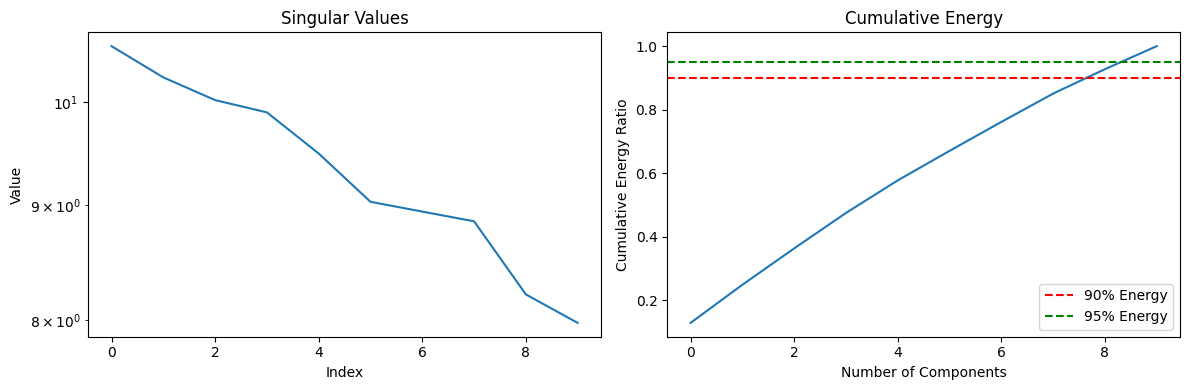

In [9]:
def apply_svd_to_weight(weight_matrix):
    """Apply SVD to a weight matrix and return U, S, V."""
    # Convert to numpy for SVD computation
    weight_np = weight_matrix.detach().cpu().numpy()
    
    # For conv layers, reshape to 2D matrix
    original_shape = weight_np.shape
    if len(original_shape) == 4:  # Conv2d weights: (out_channels, in_channels, H, W)
        weight_np = weight_np.reshape(original_shape[0], -1)
    
    # Apply SVD
    U, S, Vt = np.linalg.svd(weight_np, full_matrices=False)
    
    return U, S, Vt, original_shape

def reconstruct_weight_with_k_components(U, S, Vt, k, original_shape, device):
    """Reconstruct weight matrix using only k singular values."""
    # Truncate to k components
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    # Reconstruct
    reconstructed = U_k @ np.diag(S_k) @ Vt_k
    
    # Reshape back to original shape if needed
    if len(original_shape) == 4:
        reconstructed = reconstructed.reshape(original_shape)
    
    # Convert back to tensor
    return torch.tensor(reconstructed, dtype=torch.float32, device=device)

# Analyze SVD for the final linear layer (fc)
fc_layer = linear_layers['fc']
U, S, Vt, original_shape = apply_svd_to_weight(fc_layer.weight)

print(f"SVD analysis for final linear layer (fc):")
print(f"Original weight shape: {fc_layer.weight.shape}")
print(f"Number of singular values: {len(S)}")
print(f"Largest singular values: {S[:5]}")
print(f"Smallest singular values: {S[-5:]}")

# Plot singular values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(S)
plt.title('Singular Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')

plt.subplot(1, 2, 2)
cumulative_energy = np.cumsum(S**2) / np.sum(S**2)
plt.plot(cumulative_energy)
plt.title('Cumulative Energy')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Energy Ratio')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Energy')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Energy')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Reconstruct Model with Reduced Rank Weights

In [10]:
def create_svd_compressed_model(original_model, target_layers, k_values):
    """
    Create a compressed model using SVD with k singular values for specified layers.
    
    Args:
        original_model: The original model
        target_layers: Dict of layer names to compress
        k_values: Dict mapping layer names to number of singular values to keep
    """
    # Create a deep copy of the model
    compressed_model = copy.deepcopy(original_model)
    
    # Apply SVD compression to specified layers
    for layer_name, k in k_values.items():
        if layer_name in target_layers:
            layer = dict(compressed_model.named_modules())[layer_name]
            
            # Apply SVD to the weight
            U, S, Vt, original_shape = apply_svd_to_weight(layer.weight)
            
            # Reconstruct with k components
            reconstructed_weight = reconstruct_weight_with_k_components(
                U, S, Vt, k, original_shape, device
            )
            
            # Update the layer weight
            layer.weight.data = reconstructed_weight
            
            print(f"Compressed {layer_name}: {len(S)} → {k} singular values "
                  f"({k/len(S)*100:.1f}% retained)")
    
    return compressed_model

# Store SVD information for all linear layers
svd_info = {}
for name, layer in linear_layers.items():
    U, S, Vt, original_shape = apply_svd_to_weight(layer.weight)
    svd_info[name] = {
        'U': U, 'S': S, 'Vt': Vt, 'original_shape': original_shape,
        'total_components': len(S)
    }
    print(f"{name}: {len(S)} singular values")

# Example: Create models with different compression levels for the fc layer
k_values_list = range(1, len(svd_info['fc']['S']) + 1,)  # From 1 to full rank in steps of 10
#k_values_list = [1, 2, 5, 10, 20, 50, len(svd_info['fc']['S'])]  # Full rank as baseline
compressed_models = {}

for k in k_values_list:
    if k <= svd_info['fc']['total_components']:
        k_dict = {'fc': k}
        compressed_models[k] = create_svd_compressed_model(model, linear_layers, k_dict)
        
print(f"\nCreated {len(compressed_models)} compressed models")

fc: 10 singular values
Compressed fc: 10 → 1 singular values (10.0% retained)
Compressed fc: 10 → 2 singular values (20.0% retained)
Compressed fc: 10 → 3 singular values (30.0% retained)
Compressed fc: 10 → 4 singular values (40.0% retained)
Compressed fc: 10 → 5 singular values (50.0% retained)
Compressed fc: 10 → 6 singular values (60.0% retained)
Compressed fc: 10 → 7 singular values (70.0% retained)
Compressed fc: 10 → 8 singular values (80.0% retained)
Compressed fc: 10 → 9 singular values (90.0% retained)
Compressed fc: 10 → 10 singular values (100.0% retained)

Created 10 compressed models


## 7. Evaluate Model Performance

In [11]:
def evaluate_model(model, dataloader, max_batches=None):
    """Evaluate model accuracy on a dataset."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(dataloader):
            if max_batches and batch_idx >= max_batches:
                break
                
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

def evaluate_all_models(models_dict, train_loader, test_loader, max_batches=50):
    """Evaluate all models and return results."""
    results = {}
    
    print("Evaluating models...")
    for k, model in tqdm(models_dict.items(), desc="Models"):
        print(f"\nEvaluating model with k={k} singular values...")
        
        # Evaluate on training set (subset)
        train_acc = evaluate_model(model, train_loader, max_batches=max_batches)
        
        # Evaluate on test set (subset)
        test_acc = evaluate_model(model, test_loader, max_batches=max_batches)
        
        results[k] = {
            'train_accuracy': train_acc,
            'test_accuracy': test_acc
        }
        
        print(f"k={k}: Train Acc = {train_acc:.2f}%, Test Acc = {test_acc:.2f}%")
    
    return results

# Evaluate the original model first
print("Evaluating original model...")
original_train_acc = evaluate_model(model, trainloader, max_batches=2)
original_test_acc = evaluate_model(model, testloader, max_batches=2)
print(f"Original model: Train Acc = {original_train_acc:.2f}%, Test Acc = {original_test_acc:.2f}%")

Evaluating original model...
Original model: Train Acc = 78.52%, Test Acc = 72.27%


## 8. Compare Accuracy vs Number of Singular Values

In [12]:
# Run the evaluation experiment
print("Running SVD compression experiment...")
results = evaluate_all_models(compressed_models, trainloader, testloader, max_batches=50)

# Add original model results
original_k = svd_info['fc']['total_components']
results[original_k] = {
    'train_accuracy': original_train_acc,
    'test_accuracy': original_test_acc
}

# Sort results by k value
sorted_results = dict(sorted(results.items()))

print("\nFinal Results:")
print("k\tTrain Acc\tTest Acc\tDifference")
print("-" * 40)
for k, res in sorted_results.items():
    diff = res['train_accuracy'] - res['test_accuracy']
    print(f"{k}\t{res['train_accuracy']:.2f}%\t\t{res['test_accuracy']:.2f}%\t\t{diff:.2f}%")

Running SVD compression experiment...
Evaluating models...


Models:   0%|          | 0/10 [00:00<?, ?it/s]


Evaluating model with k=1 singular values...


Models:  10%|█         | 1/10 [00:34<05:06, 34.01s/it]

k=1: Train Acc = 17.33%, Test Acc = 17.05%

Evaluating model with k=2 singular values...


...

k=8: Train Acc = 61.94%, Test Acc = 55.94%

Evaluating model with k=9 singular values...


Models:  90%|█████████ | 9/10 [07:57<01:00, 60.57s/it]

k=9: Train Acc = 73.39%, Test Acc = 63.92%

Evaluating model with k=10 singular values...


Models: 100%|██████████| 10/10 [08:29<00:00, 50.99s/it]

k=10: Train Acc = 82.62%, Test Acc = 71.70%

Final Results:
k	Train Acc	Test Acc	Difference
----------------------------------------
1	17.33%		17.05%		0.28%
2	20.34%		19.83%		0.52%
3	25.20%		23.48%		1.72%
4	27.98%		26.36%		1.62%
5	39.81%		36.48%		3.33%
6	46.28%		41.31%		4.97%
7	51.55%		46.38%		5.17%
8	61.94%		55.94%		6.00%
9	73.39%		63.92%		9.47%
10	78.52%		72.27%		6.25%


## 9. Visualize Results

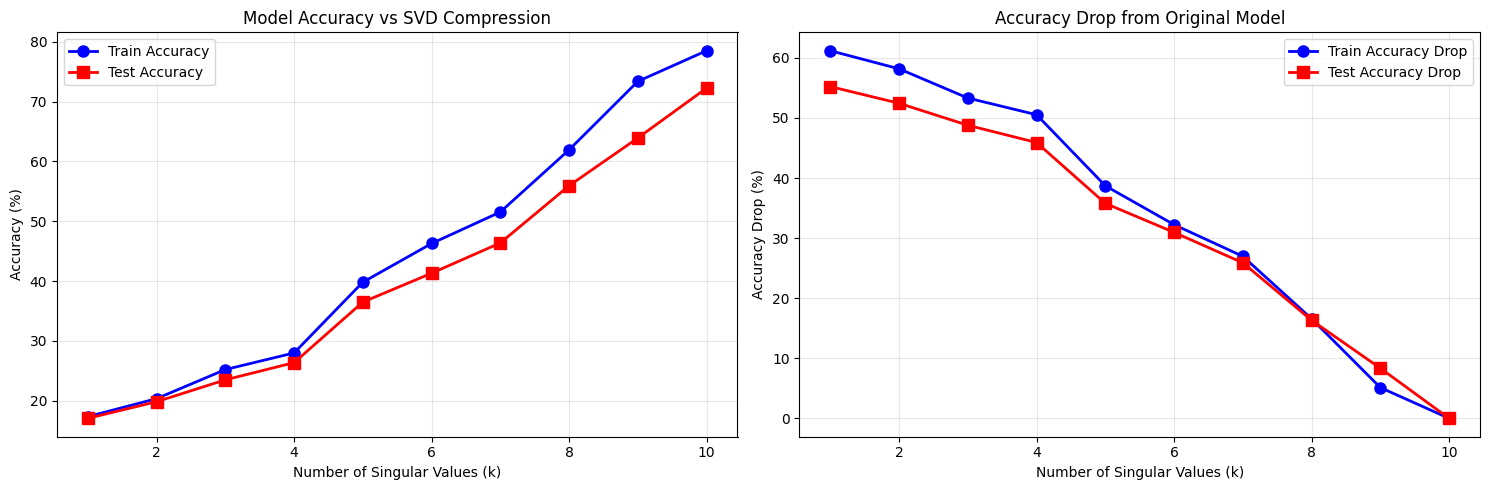

In [13]:
# Create visualization with only the first two plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Extract data for plotting
k_values = list(sorted_results.keys())
train_accs = [sorted_results[k]['train_accuracy'] for k in k_values]
test_accs = [sorted_results[k]['test_accuracy'] for k in k_values]

# Plot 1: Accuracy vs Number of Singular Values
axes[0].plot(k_values, train_accs, 'b-o', label='Train Accuracy', linewidth=2, markersize=8)
axes[0].plot(k_values, test_accs, 'r-s', label='Test Accuracy', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Singular Values (k)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy vs SVD Compression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy Drop from Original
original_train = train_accs[-1]  # Last value (full rank)
original_test = test_accs[-1]
train_drops = [original_train - acc for acc in train_accs]
test_drops = [original_test - acc for acc in test_accs]

axes[1].plot(k_values, train_drops, 'b-o', label='Train Accuracy Drop', linewidth=2, markersize=8)
axes[1].plot(k_values, test_drops, 'r-s', label='Test Accuracy Drop', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Singular Values (k)')
axes[1].set_ylabel('Accuracy Drop (%)')
axes[1].set_title('Accuracy Drop from Original Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
